# Llama-3.1-70B — Spot Tolerance Analysis (Scenario A)

Llama-3.1-70B-Instruct, 2 pipelines (SS-P1: 6 stages on g6.12xlarge + g6e.xlarge, SS-P2: 3 stages on g5.12xlarge + g6.12xlarge)

**Duration**: 60 minutes | **Benchmark**: offline (saturated) + online (Poisson arrival)

**Events** (Scenario A):

| Time | Type | Instances |
|------|------|-----------|
| t=5 min | Interruption | g6e.xlarge ×4 |
| t=15 min | Restore | g6e.xlarge ×4 |
| t=25 min | Interrupt + Restore | g6e.xlarge ×4 (interrupt) + g5.12xlarge ×2 (restore) |
| t=35 min | Restore | g6e.xlarge ×4 |
| t=45 min | Interruption | g6e.xlarge ×4 + g5.12xlarge ×2 |

| System | Mode | Event Handling |
|--------|------|----------------|
| OnlyOnDemand | default | none (baseline) |
| ShuntServe | migration | switch_nodes (hot) |
| ConcurrentInit | re-routing | switch_nodes (hot) |
| RequestMigration | migration | stop_nodes + create_pipeline (cold) |
| NoHandle | re-routing | stop_nodes + create_pipeline (cold) |

In [17]:
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

SYSTEMS = ["OnlyOnDemand", "ShuntServe", "ConcurrentInit", "RequestMigration", "NoHandle"]
COLORS = {
    "OnlyOnDemand": "#808080",
    "ShuntServe": "#1f77b4",
    "ConcurrentInit": "#ff7f0e",
    "RequestMigration": "#2ca02c",
    "NoHandle": "#d62728",
}
DISPLAY_NAMES = {
    "OnlyOnDemand": "On-demand Only",
    "ShuntServe": "ShuntServe",
    "ConcurrentInit": "Concurrent Initialization",
    "RequestMigration": "Request Migration",
    "NoHandle": "No Handle",
}
HATCHES = {
    "OnlyOnDemand": "",
    "ShuntServe": ".",
    "ConcurrentInit": "x",
    "RequestMigration": "\\",
    "NoHandle": "/",
}
BAR_KW = dict(alpha=0.7, edgecolor='black', linewidth=1.5)

EVENT_TIMES_MIN = [5, 15, 25, 35, 45]
EVENT_LABELS = [
    "interrupt\ng6e×4",
    "restore\ng6e×4",
    "interrupt g6e×4\n+ restore g5×2",
    "restore\ng6e×4",
    "interrupt\ng6e×4 + g5×2",
]

DURATION_SEC = 3000

In [18]:
# --- Utility: Trailing Moving Average RPS ---
def calculate_rps_with_moving_average(df, window=5, max_time=None):
    """
    Calculate requests per second (RPS) with trailing moving average.
    Window covers [t - window, t).
    """
    base_time = df['ArrivalTime'].min()
    completion_times = df['CompletionTime'].values - base_time

    if max_time is None:
        max_time_calc = int(np.ceil(completion_times.max()))
    else:
        max_time_calc = max_time

    time_points = np.arange(0, max_time_calc + 1)
    rps_values = []

    for t in time_points:
        if window <= 0:
            count = np.sum((completion_times >= t) & (completion_times < t + 1))
        else:
            window_start = max(0, t - window)
            window_end = t
            count = np.sum((completion_times >= window_start) & (completion_times < window_end))
            count = count / window
        rps_values.append(count)

    return time_points, np.array(rps_values)


# --- Plotting order for paper figures (bar charts & timelines) ---
PAPER_ORDER = ["OnlyOnDemand", "NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]
PAPER_COLORS_ORDERED = [COLORS[s] for s in PAPER_ORDER]
PAPER_HATCHES_ORDERED = [HATCHES[s] for s in PAPER_ORDER]
PAPER_LABELS_ORDERED = [DISPLAY_NAMES[s] for s in PAPER_ORDER]

# Timeline plot order (exclude OnlyOnDemand from lines, show separately if needed)
TIMELINE_ORDER = ["NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]

---
# Part I: Offline Analysis
## Load Offline JSON Results

In [19]:
OFFLINE_DIR = "offline/scenario_A"

offline_json_files = {
    "OnlyOnDemand": "offline_only_ondemand.json",
    "ShuntServe": "offline_shuntserve.json",
    "ConcurrentInit": "offline_concurrent_initialization.json",
    "RequestMigration": "offline_request_migration.json",
    "NoHandle": "offline_no_handle.json",
}

offline_results = {}
for name, fname in offline_json_files.items():
    with open(f"{OFFLINE_DIR}/{fname}") as f:
        offline_results[name] = json.load(f)

df_offline = pd.DataFrame([
    {"system": name, **{k: v for k, v in data.items() if not isinstance(v, (dict, list))}}
    for name, data in offline_results.items()
]).set_index("system")

df_offline[["completed", "request_throughput", "output_throughput", "total_token_throughput",
            "mean_ttft_ms", "median_ttft_ms", "mean_tpot_ms", "mean_e2el_ms", "benchmark_duration"]]

,completed,request_throughput,output_throughput,total_token_throughput,mean_ttft_ms,median_ttft_ms,mean_tpot_ms,mean_e2el_ms,benchmark_duration
system,,,,,,,,,
OnlyOnDemand,4757,1.321203,356.917535,1451.902285,67703.177975,64229.420900,1008.245312,331397.793056,3600.506765
ShuntServe,4295,1.192885,323.580259,1326.234821,62303.201833,59353.785038,1224.152645,365502.383245,3600.513217
ConcurrentInitialization,3968,1.101969,296.623630,1224.994855,155840.022462,97431.198835,1007.095215,394044.869524,3600.825735
RequestMigration,3691,1.025070,274.951694,1138.852463,60995.968194,59803.341866,1489.345372,421471.198676,3600.730678
NoHandle,3429,0.952268,252.110764,1051.970224,212871.796360,138343.770742,1006.869409,447834.897060,3600.877586


## Offline Throughput Comparison

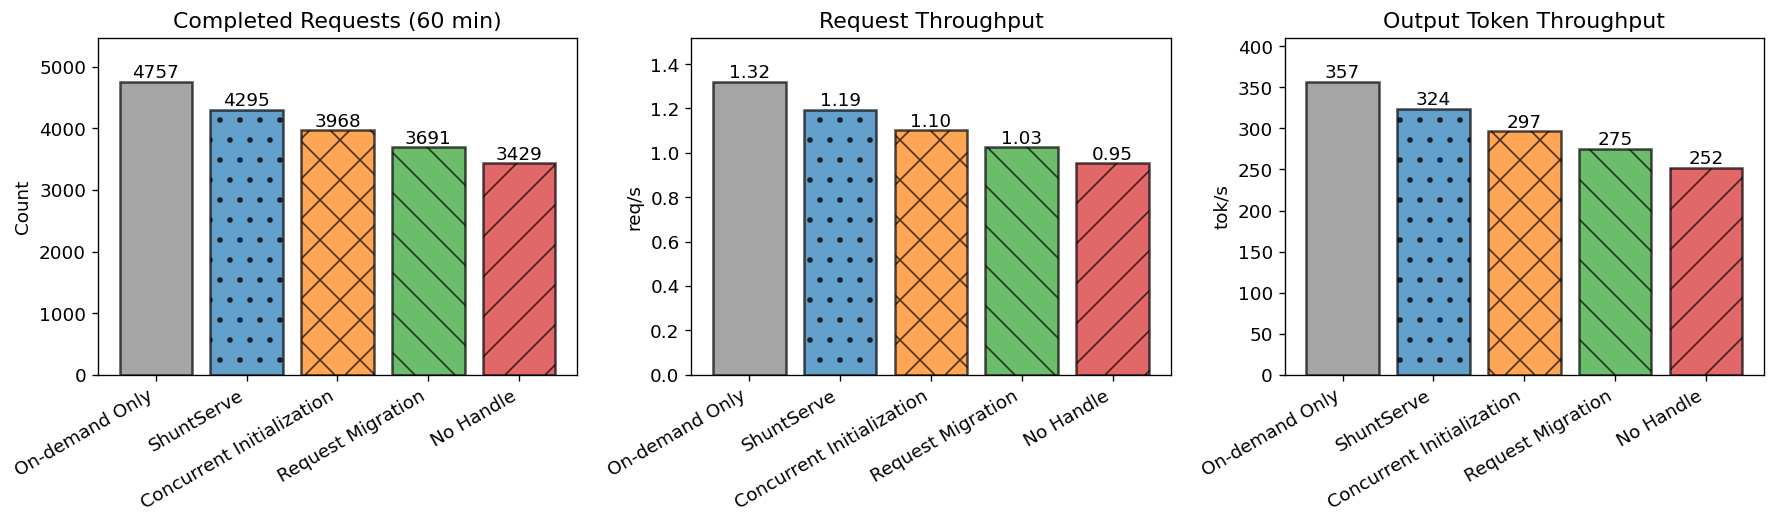

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
display_labels = [DISPLAY_NAMES[s] for s in SYSTEMS]

for ax, key, title, ylabel, fmt in [
    (axes[0], "completed", "Completed Requests (60 min)", "Count", "%d"),
    (axes[1], "request_throughput", "Request Throughput", "req/s", "%.2f"),
    (axes[2], "output_throughput", "Output Token Throughput", "tok/s", "%.0f"),
]:
    vals = [offline_results[s][key] for s in SYSTEMS]
    bars = []
    for i, s in enumerate(SYSTEMS):
        bar = ax.bar(i, vals[i], color=COLORS[s], hatch=HATCHES[s], **BAR_KW)
        bars.append(bar)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(SYSTEMS)))
    ax.set_xticklabels(display_labels, rotation=30, ha='right')
    ax.set_ylim(0, max(vals) * 1.15)
    for bar_container, v in zip(bars, vals):
        ax.bar_label(bar_container, fmt=fmt)

plt.tight_layout()
plt.show()

## Load Offline CSV Traces

In [21]:
OFFLINE_TRACE_DIR = f"{OFFLINE_DIR}/Trace"
offline_csv_files = {
    "OnlyOnDemand": sorted(glob.glob(f"{OFFLINE_TRACE_DIR}/spottolerance_offline_only_ondemand_*.csv"))[-1],
    "ShuntServe": sorted(glob.glob(f"{OFFLINE_TRACE_DIR}/spottolerance_offline_shuntserve_*.csv"))[-1],
    "ConcurrentInit": sorted(glob.glob(f"{OFFLINE_TRACE_DIR}/spottolerance_offline_concurrent_initialization_*.csv"))[-1],
    "RequestMigration": sorted(glob.glob(f"{OFFLINE_TRACE_DIR}/spottolerance_offline_request_migration_*.csv"))[-1],
    "NoHandle": sorted(glob.glob(f"{OFFLINE_TRACE_DIR}/spottolerance_offline_no_handle_*.csv"))[-1],
}

offline_traces = {}
for name, path in offline_csv_files.items():
    df = pd.read_csv(path)
    df["system"] = name
    t0 = df["ArrivalTime"].min()
    df["arrival_min"] = (df["ArrivalTime"] - t0) / 60
    df["completion_min"] = (df["CompletionTime"] - t0) / 60
    offline_traces[name] = df
    print(f"{name}: {len(df)} requests, {path.split('/')[-1]}")

OnlyOnDemand: 4757 requests, spottolerance_offline_only_ondemand_llama3_70b_scenario_A_20260322_1116.csv
ShuntServe: 4295 requests, spottolerance_offline_shuntserve_scenario_A_20260322_0701.csv
ConcurrentInit: 3968 requests, spottolerance_offline_concurrent_initialization_llama3_70b_scenario_A_20260322_0805.csv
RequestMigration: 3691 requests, spottolerance_offline_request_migration_llama3_70b_scenario_A_20260322_0910.csv
NoHandle: 3429 requests, spottolerance_offline_no_handle_llama3_70b_scenario_A_20260322_1013.csv


## Offline Throughput Timeline & Average (trailing 10-min window)

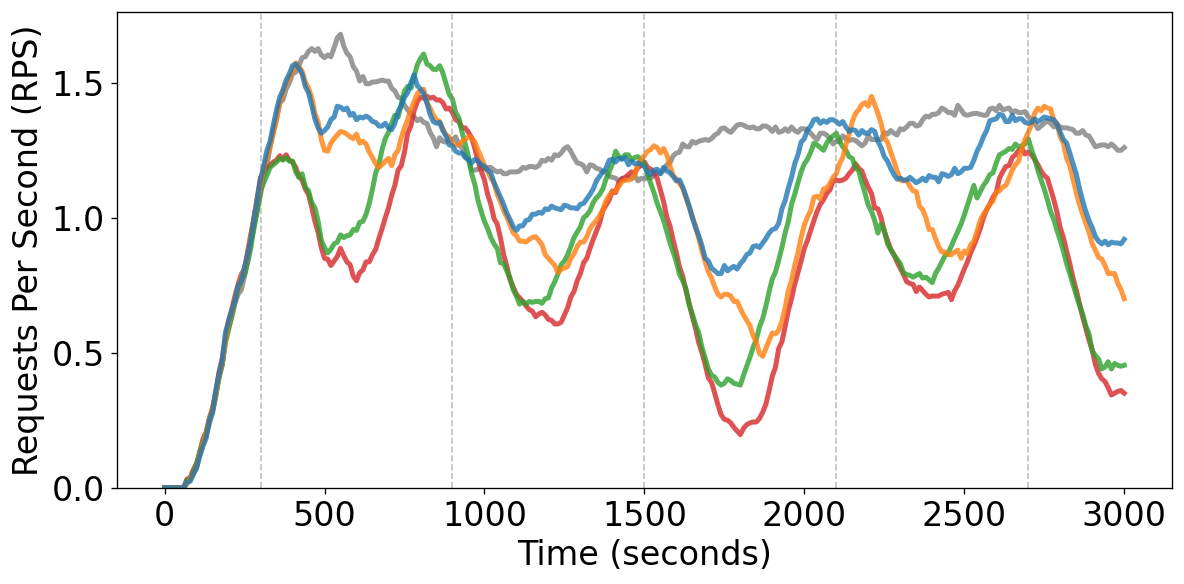

On-demand Only               — Avg RPS: 1.23, Peak: 1.68
No Handle                    — Avg RPS: 0.85, Peak: 1.47
Request Migration            — Avg RPS: 0.92, Peak: 1.62
Concurrent Initialization    — Avg RPS: 1.03, Peak: 1.58
ShuntServe                   — Avg RPS: 1.12, Peak: 1.58


In [22]:
# --- Offline Throughput Timeline (paper-ready, trailing moving average) ---
window_size = 300  # 5-min trailing window
duration = DURATION_SEC
stride = 10
fs = 20

# Calculate RPS for each system
offline_rps = {}
offline_times = {}
for name in SYSTEMS:
    t, rps = calculate_rps_with_moving_average(offline_traces[name], window=window_size, max_time=duration)
    offline_times[name] = t
    offline_rps[name] = rps

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

plot_order = ["OnlyOnDemand", "NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]
max_rps = 0
min_rps = float('inf')

for name in plot_order:
    if name not in offline_rps:
        continue
    t = offline_times[name][::stride]
    rps = offline_rps[name][::stride]
    max_rps = max(max_rps, np.max(offline_rps[name]))
    min_rps = min(min_rps, np.min(offline_rps[name]))

    ax.plot(t, rps, label=DISPLAY_NAMES[name], color=COLORS[name], linewidth=3, alpha=0.8)

# Event vertical lines
for t_min in EVENT_TIMES_MIN:
    ax.axvline(x=t_min * 60, color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax.set_xlabel('Time (seconds)', fontsize=fs)
ax.set_ylabel('Requests Per Second (RPS)', fontsize=fs)
ax.set_ylim(min_rps, max_rps * 1.05)
ax.tick_params(axis='both', labelsize=fs)
plt.tight_layout()
plt.savefig("../figures/llama3_70b_scenario_A_offline_throughput_timeline.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Print summary
for name in plot_order:
    if name in offline_rps:
        print(f"{DISPLAY_NAMES[name]:28s} — Avg RPS: {np.mean(offline_rps[name]):.2f}, Peak: {np.max(offline_rps[name]):.2f}")

/tmp/ipykernel_785559/1669553772.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


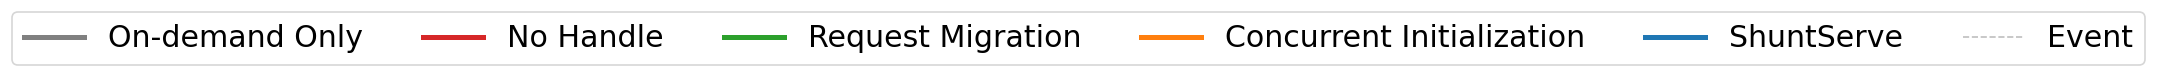

In [23]:
# --- Separate Legend Figure ---
fig_leg, ax_leg = plt.subplots(figsize=(10, 0.5))
ax_leg.axis('off')

plot_order = ["OnlyOnDemand", "NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]
handles = [plt.Line2D([0], [0], color=COLORS[name], linewidth=3) for name in plot_order]
labels = [DISPLAY_NAMES[name] for name in plot_order]

# Add event line entry
handles.append(plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=1, alpha=0.5))
labels.append('Event')

ax_leg.legend(handles, labels, loc='center', ncol=6, frameon=True, fontsize=18)
plt.tight_layout()
plt.savefig("../figures/llama3_70b_scenario_A_timeline_legend.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Offline Ablation Summary — 2×2 Matrix (Hot/Cold × Migration/Re-routing)

In [24]:
ablation = {
    ("Hot (switch_nodes)", "Migration"): "ShuntServe",
    ("Hot (switch_nodes)", "Re-routing"): "ConcurrentInit",
    ("Cold (stop+create)", "Migration"): "RequestMigration",
    ("Cold (stop+create)", "Re-routing"): "NoHandle",
}

rows = ["Hot (switch_nodes)", "Cold (stop+create)"]
cols = ["Migration", "Re-routing"]

print("=" * 90)
print(f"{'':25s} | {'Migration':30s} | {'Re-routing':30s}")
print("-" * 90)
for row in rows:
    cells = []
    for col in cols:
        s = ablation[(row, col)]
        dn = DISPLAY_NAMES[s]
        cell = f"{dn}\n  completed={offline_results[s]['completed']}\n  req/s={offline_results[s]['request_throughput']:.2f}\n  E2E={offline_results[s]['mean_e2el_ms']/1000:.1f}s\n  TTFT={offline_results[s]['mean_ttft_ms']/1000:.1f}s"
        cells.append(cell)
    lines_left = cells[0].split("\n")
    lines_right = cells[1].split("\n")
    max_lines = max(len(lines_left), len(lines_right))
    for i in range(max_lines):
        left = lines_left[i] if i < len(lines_left) else ""
        right = lines_right[i] if i < len(lines_right) else ""
        prefix = row if i == 0 else ""
        print(f"{prefix:25s} | {left:30s} | {right:30s}")
    print("-" * 90)

# Normalized comparison table (baseline = OnlyOnDemand)
print(f"\n\nNormalized to {DISPLAY_NAMES['OnlyOnDemand']} (baseline = 1.00):")
print(f"{'System':28s} {'Completed':>10s} {'Req/s':>10s} {'E2E':>10s} {'TTFT':>10s}")
base = offline_results["OnlyOnDemand"]
for name in SYSTEMS:
    r = offline_results[name]
    print(f"{DISPLAY_NAMES[name]:28s} "
          f"{r['completed']/base['completed']:10.2f} "
          f"{r['request_throughput']/base['request_throughput']:10.2f} "
          f"{r['mean_e2el_ms']/base['mean_e2el_ms']:10.2f} "
          f"{r['mean_ttft_ms']/base['mean_ttft_ms']:10.2f}")

                          | Migration                      | Re-routing                    
------------------------------------------------------------------------------------------
Hot (switch_nodes)        | ShuntServe                     | Concurrent Initialization     
                          |   completed=4295               |   completed=3968              
                          |   req/s=1.19                   |   req/s=1.10                  
                          |   E2E=365.5s                   |   E2E=394.0s                  
                          |   TTFT=62.3s                   |   TTFT=155.8s                 
------------------------------------------------------------------------------------------
Cold (stop+create)        | Request Migration              | No Handle                     
                          |   completed=3691               |   completed=3429              
                          |   req/s=1.03                   |   req/s=0.95         

---
# Part II: Online Analysis
## Load Online JSON Results

In [25]:
ONLINE_DIR = "online/scenario_A"

online_json_files = {
    "OnlyOnDemand": "online_only_ondemand.json",
    "ShuntServe": "online_shuntserve.json",
    "ConcurrentInit": "online_concurrent_initialization.json",
    "RequestMigration": "online_request_migration.json",
    "NoHandle": "online_no_handle.json",
}

online_results = {}
for name, fname in online_json_files.items():
    with open(f"{ONLINE_DIR}/{fname}") as f:
        online_results[name] = json.load(f)

df_online = pd.DataFrame([
    {"system": name, **{k: v for k, v in data.items() if not isinstance(v, (dict, list))}}
    for name, data in online_results.items()
]).set_index("system")

df_online[["completed", "request_throughput", "output_throughput", "total_token_throughput",
           "mean_ttft_ms", "median_ttft_ms", "mean_tpot_ms", "mean_e2el_ms", "benchmark_duration"]]

,completed,request_throughput,output_throughput,total_token_throughput,mean_ttft_ms,median_ttft_ms,mean_tpot_ms,mean_e2el_ms,benchmark_duration
system,,,,,,,,,
OnlyOnDemand,2494,0.692699,193.750675,780.286821,1661.452877,1492.017031,382.660408,109337.602790,3600.410673
ShuntServe,2500,0.694365,194.183650,782.321738,2109.815125,1549.526930,399.928393,115071.428572,3600.411265
ConcurrentInitialization,2494,0.692697,193.755830,780.344092,16525.721529,1796.916962,389.390928,126090.662002,3600.418108
RequestMigration,2495,0.692975,193.679347,780.838064,12322.951738,1780.549049,535.453017,153735.863102,3600.420022
NoHandle,2494,0.692696,193.564512,779.705458,27278.597647,2095.486164,500.485823,160749.802331,3600.427536


## Load Online CSV Traces

In [26]:
ONLINE_TRACE_DIR = f"{ONLINE_DIR}/Trace"
online_csv_files = {
    "OnlyOnDemand": sorted(glob.glob(f"{ONLINE_TRACE_DIR}/spottolerance_online_only_ondemand_*.csv"))[-1],
    "ShuntServe": sorted(glob.glob(f"{ONLINE_TRACE_DIR}/spottolerance_online_shuntserve_*.csv"))[-1],
    "ConcurrentInit": sorted(glob.glob(f"{ONLINE_TRACE_DIR}/spottolerance_online_concurrent_initialization_*.csv"))[-1],
    "RequestMigration": sorted(glob.glob(f"{ONLINE_TRACE_DIR}/spottolerance_online_request_migration_*.csv"))[-1],
    "NoHandle": sorted(glob.glob(f"{ONLINE_TRACE_DIR}/spottolerance_online_no_handle_*.csv"))[-1],
}

online_traces = {}
for name, path in online_csv_files.items():
    df = pd.read_csv(path)
    df["system"] = name
    t0 = df["ArrivalTime"].min()
    df["arrival_min"] = (df["ArrivalTime"] - t0) / 60
    df["completion_min"] = (df["CompletionTime"] - t0) / 60
    online_traces[name] = df
    print(f"{name}: {len(df)} requests, {path.split('/')[-1]}")

OnlyOnDemand: 2494 requests, spottolerance_online_only_ondemand_llama3_70b_scenario_A_20260323_2320.csv
ShuntServe: 2500 requests, spottolerance_online_shuntserve_scenario_A_20260323_1157.csv
ConcurrentInit: 2494 requests, spottolerance_online_concurrent_initialization_llama3_70b_scenario_A_20260323_1354.csv
RequestMigration: 2495 requests, spottolerance_online_request_migration_llama3_70b_scenario_A_20260323_2218.csv
NoHandle: 2494 requests, spottolerance_online_no_handle_llama3_70b_scenario_A_20260323_1054.csv


## Online E2E Latency Timeline (trailing 10-min window, mean & P90)

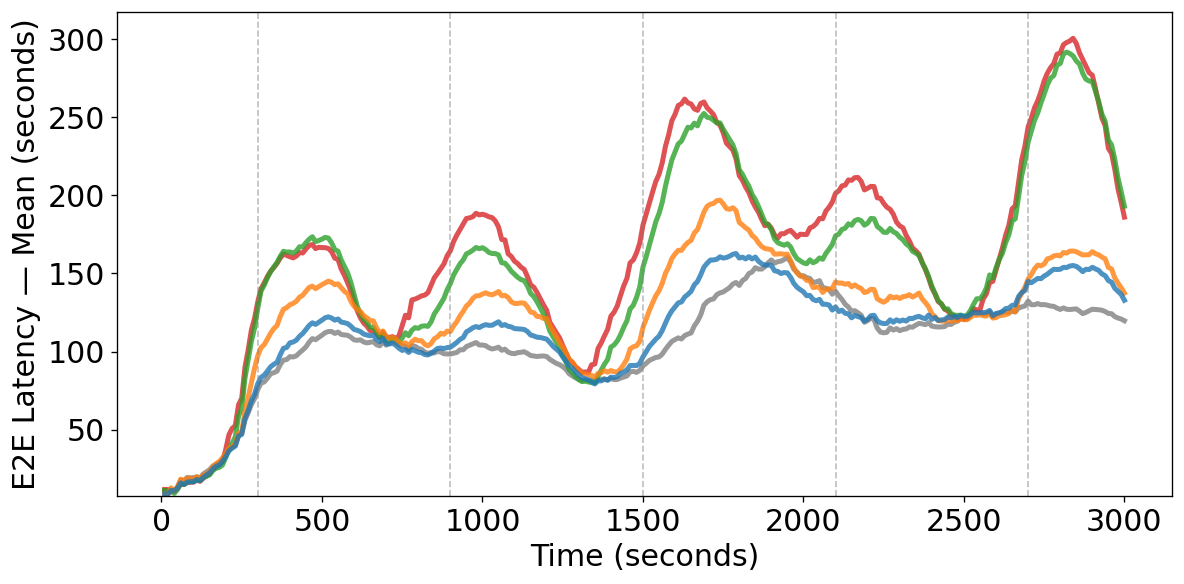

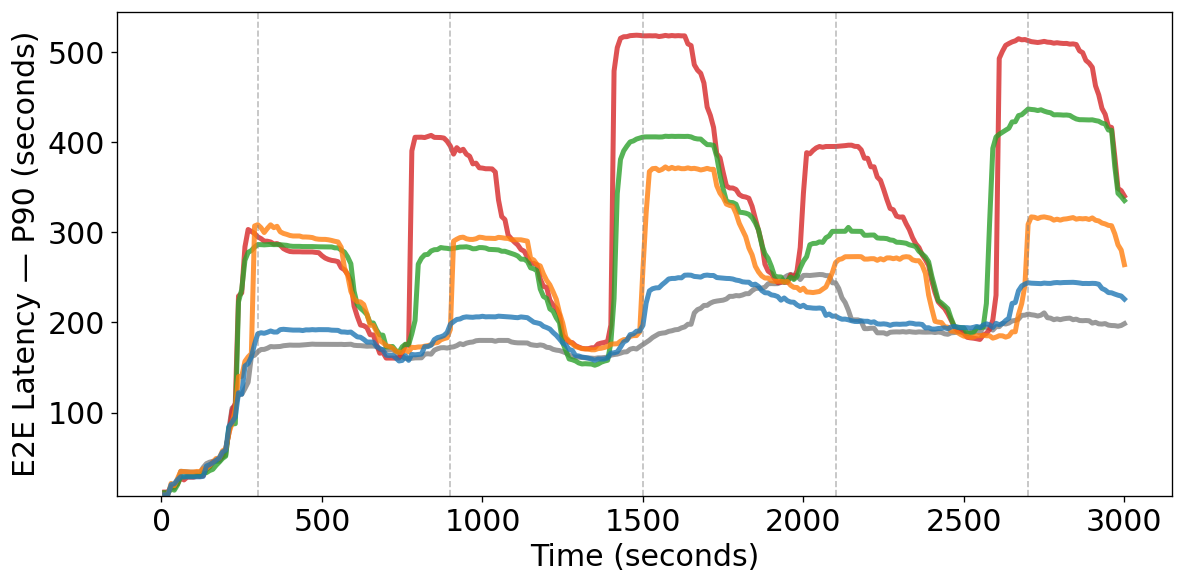

In [27]:
# --- Online E2E Latency Timeline (paper-ready, trailing window, mean & P90) ---
LATENCY_WINDOW_SEC = 300
stride = 10
fs = 18

plot_order = ["OnlyOnDemand", "NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]

for stat_name, stat_func, fname in [
    ("Mean", lambda x: np.mean(x), "../figures/llama3_70b_scenario_A_online_e2e_mean_timeline.pdf"),
    ("P90", lambda x: np.percentile(x, 90), "../figures/llama3_70b_scenario_A_online_e2e_p90_timeline.pdf"),
]:
    fig, ax = plt.subplots(figsize=(10, 5))
    max_val = 0
    min_val = float('inf')

    for name in plot_order:
        df = online_traces[name]
        t0 = df["ArrivalTime"].min()
        arrivals = (df["ArrivalTime"] - t0).values
        latencies = df["Latency"].values

        sort_idx = np.argsort(arrivals)
        arrivals = arrivals[sort_idx]
        latencies = latencies[sort_idx]

        time_points = np.arange(0, DURATION_SEC + 1)
        stats = []
        for t in time_points:
            w_start = max(0, t - LATENCY_WINDOW_SEC)
            w_end = t
            mask = (arrivals >= w_start) & (arrivals < w_end)
            if mask.sum() > 0:
                stats.append(stat_func(latencies[mask]))
            else:
                stats.append(np.nan)
        stats = np.array(stats)

        t_plot = time_points[::stride]
        s_plot = stats[::stride]
        valid = ~np.isnan(s_plot)
        max_val = max(max_val, np.nanmax(stats))
        min_val = min(min_val, np.nanmin(stats))

        ax.plot(t_plot[valid], s_plot[valid], label=DISPLAY_NAMES[name],
                color=COLORS[name], linewidth=3, alpha=0.8)

    # Event vertical lines
    for t_min in EVENT_TIMES_MIN:
        ax.axvline(x=t_min * 60, color='gray', linestyle='--', alpha=0.5, linewidth=1)

    ax.set_xlabel('Time (seconds)', fontsize=fs)
    ax.set_ylabel(f'E2E Latency — {stat_name} (seconds)', fontsize=fs)
    ax.set_ylim(min_val * 0.9, max_val * 1.05)
    ax.tick_params(axis='both', labelsize=fs)
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

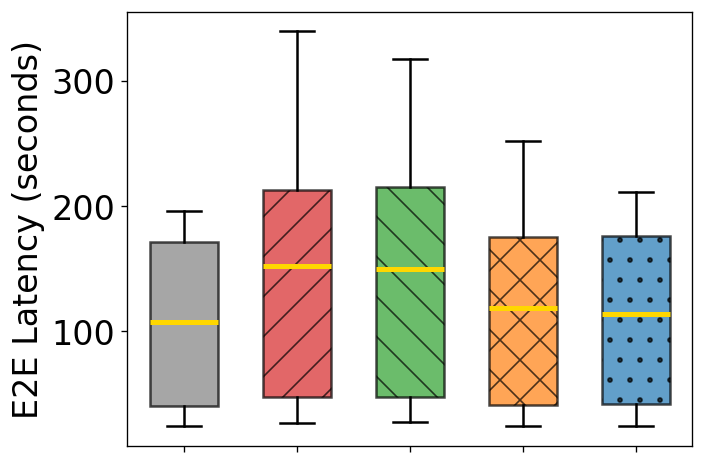

In [28]:
# --- Online E2E Latency Box Plot (whisker=P5/P95, box=P25/P75, median=yellow) ---
fs = 20
plot_order = ["OnlyOnDemand", "NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]
colors = [COLORS[name] for name in plot_order]
hatches = [HATCHES[name] for name in plot_order]

data = [online_traces[name]["Latency"].values for name in plot_order]

fig, ax = plt.subplots(figsize=(6, 4))

bp = ax.boxplot(data, patch_artist=True, widths=0.6,
                whis=[10, 90],
                showfliers=False,
                medianprops=dict(color='#FFD700', linewidth=3),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))

for patch, color, hatch in zip(bp['boxes'], colors, hatches):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)
    patch.set_hatch(hatch)

ax.set_ylabel('E2E Latency (seconds)', fontsize=fs)
ax.tick_params(axis='y', labelsize=fs)
ax.tick_params(axis='x', labelbottom=False)

plt.tight_layout()
plt.savefig("../figures/llama3_70b_scenario_A_online_e2e_boxplot.pdf", dpi=300, bbox_inches='tight')
plt.show()

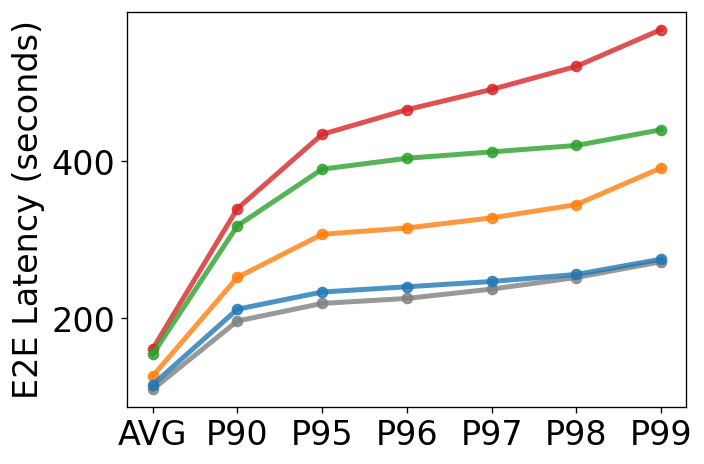

In [29]:
# --- Online E2E Latency Percentile Line Plot ---
fs = 20
plot_order = ["OnlyOnDemand", "NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]
pct_labels = ["AVG", "P90", "P95", "P96", "P97", "P98", "P99"]
pct_values = [90, 95, 96, 97, 98, 99]

fig, ax = plt.subplots(figsize=(6, 4))

for name in plot_order:
    data = online_traces[name]["Latency"].values
    avg = np.mean(data)
    pcts = np.percentile(data, pct_values)
    y = np.concatenate([[avg], pcts])

    ax.plot(pct_labels, y, color=COLORS[name], linewidth=3, alpha=0.8,
            marker='o', markersize=6)

ax.set_ylabel('E2E Latency (seconds)', fontsize=fs)
ax.tick_params(axis='both', labelsize=fs)

plt.tight_layout()
plt.savefig("../figures/llama3_70b_scenario_A_online_e2e_percentiles.pdf", dpi=300, bbox_inches='tight')
plt.show()

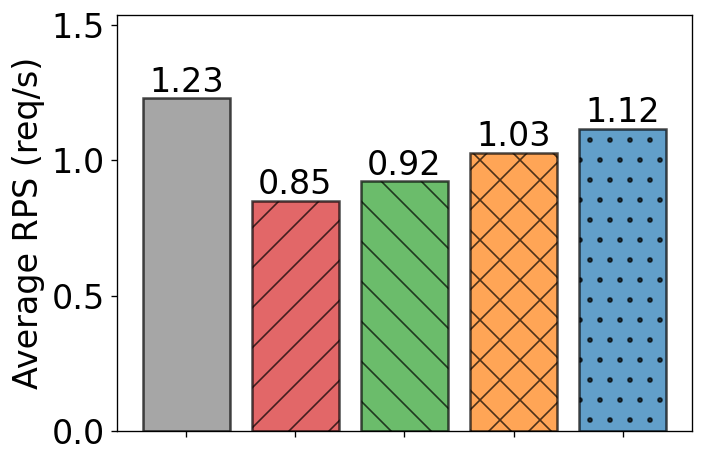

In [30]:
# --- Offline Average Throughput Bar Chart ---
fs = 20
plot_order = ["OnlyOnDemand", "NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]
colors = [COLORS[name] for name in plot_order]
hatches = [HATCHES[name] for name in plot_order]

avg_values = [np.mean(offline_rps[name]) for name in plot_order]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(range(len(plot_order)), avg_values, width=0.8, color=colors, alpha=0.7,
              edgecolor='black', linewidth=1.5, hatch=hatches)

for bar, val in zip(bars, avg_values):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
            f'{val:.2f}', ha='center', va='bottom', fontsize=fs)

ax.set_ylabel('Average RPS (req/s)', fontsize=fs)
ax.set_ylim(0, max(avg_values) * 1.25)
ax.tick_params(axis='y', labelsize=fs)
ax.tick_params(axis='x', labelbottom=False)

plt.tight_layout()
plt.savefig("../figures/llama3_70b_scenario_A_offline_avg_throughput.pdf", dpi=300, bbox_inches='tight')
plt.show()

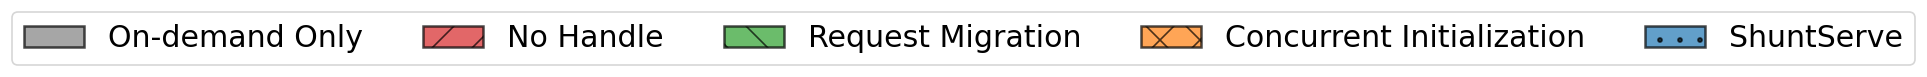

In [31]:
# --- Shared Bar/Box Legend ---
from matplotlib.patches import Patch

fs = 18
plot_order = ["OnlyOnDemand", "NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]

fig_leg, ax_leg = plt.subplots(figsize=(10, 0.5))
ax_leg.axis('off')

handles = [Patch(facecolor=COLORS[name], edgecolor='black', linewidth=1.5,
                 hatch=HATCHES[name], alpha=0.7, label=DISPLAY_NAMES[name])
           for name in plot_order]

ax_leg.legend(handles=handles, loc='center', ncol=5, frameon=True, fontsize=fs)
plt.tight_layout()
plt.savefig("../figures/llama3_70b_scenario_A_bar_legend.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Online Ablation Summary — 2×2 Matrix (Hot/Cold × Migration/Re-routing)

In [32]:
ablation_online = {
    ("Hot (switch_nodes)", "Migration"): "ShuntServe",
    ("Hot (switch_nodes)", "Re-routing"): "ConcurrentInit",
    ("Cold (stop+create)", "Migration"): "RequestMigration",
    ("Cold (stop+create)", "Re-routing"): "NoHandle",
}

rows = ["Hot (switch_nodes)", "Cold (stop+create)"]
cols = ["Migration", "Re-routing"]

print("=" * 90)
print(f"{'':25s} | {'Migration':30s} | {'Re-routing':30s}")
print("-" * 90)
for row in rows:
    cells = []
    for col in cols:
        s = ablation_online[(row, col)]
        dn = DISPLAY_NAMES[s]
        cell = f"{dn}\n  completed={online_results[s]['completed']}\n  req/s={online_results[s]['request_throughput']:.2f}\n  E2E={online_results[s]['mean_e2el_ms']/1000:.1f}s\n  TTFT={online_results[s]['mean_ttft_ms']/1000:.1f}s"
        cells.append(cell)
    lines_left = cells[0].split("\n")
    lines_right = cells[1].split("\n")
    max_lines = max(len(lines_left), len(lines_right))
    for i in range(max_lines):
        left = lines_left[i] if i < len(lines_left) else ""
        right = lines_right[i] if i < len(lines_right) else ""
        prefix = row if i == 0 else ""
        print(f"{prefix:25s} | {left:30s} | {right:30s}")
    print("-" * 90)

# Normalized comparison table (baseline = OnlyOnDemand)
print(f"\n\nNormalized to {DISPLAY_NAMES['OnlyOnDemand']} (baseline = 1.00):")
print(f"{'System':28s} {'Completed':>10s} {'Req/s':>10s} {'E2E':>10s} {'TTFT':>10s}")
base = online_results["OnlyOnDemand"]
for name in SYSTEMS:
    r = online_results[name]
    print(f"{DISPLAY_NAMES[name]:28s} "
          f"{r['completed']/base['completed']:10.2f} "
          f"{r['request_throughput']/base['request_throughput']:10.2f} "
          f"{r['mean_e2el_ms']/base['mean_e2el_ms']:10.2f} "
          f"{r['mean_ttft_ms']/base['mean_ttft_ms']:10.2f}")

                          | Migration                      | Re-routing                    
------------------------------------------------------------------------------------------
Hot (switch_nodes)        | ShuntServe                     | Concurrent Initialization     
                          |   completed=2500               |   completed=2494              
                          |   req/s=0.69                   |   req/s=0.69                  
                          |   E2E=115.1s                   |   E2E=126.1s                  
                          |   TTFT=2.1s                    |   TTFT=16.5s                  
------------------------------------------------------------------------------------------
Cold (stop+create)        | Request Migration              | No Handle                     
                          |   completed=2495               |   completed=2494              
                          |   req/s=0.69                   |   req/s=0.69         